# Airbnb Boston Price Prediction

Data source: `listings.csv` (raw Inside Airbnb data for Boston)

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100


In [70]:
# Load data
import os

DATA_PATH = os.path.join(os.getcwd(), 'listings.csv')
df = pd.read_csv(DATA_PATH)
print("Raw data shape:", df.shape)
df.head()


Raw data shape: (4419, 79)


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,3781,https://www.airbnb.com/rooms/3781,20250923202714,2025-09-23,city scrape,HARBORSIDE-Walk to subway,Fully separate apartment in a two apartment bu...,"Mostly quiet ( no loud music, no crowed sidewa...",https://a0.muscache.com/pictures/24670/b2de044...,4804,...,4.96,4.85,4.88,NaN,f,1,1,0,0,0.21
1,5506,https://www.airbnb.com/rooms/5506,20250923202714,2025-09-24,city scrape,** Fort Hill Inn Private! Minutes to center!**,**THE BEST Value in BOSTON!!*** PRIVATE GUEST ...,"Peaceful, Architecturally interesting, histori...",https://a0.muscache.com/pictures/miso/Hosting-...,8229,...,4.90,4.58,4.77,STR-490093,f,11,11,0,0,0.69
2,6695,https://www.airbnb.com/rooms/6695,20250923202714,2025-09-24,city scrape,"Fort Hill Inn *Sunny* 1 bedroom, condo duplex","Comfortable, Fully Equipped private apartment...","Peaceful, Architecturally interesting, histori...",https://a0.muscache.com/pictures/38ac4797-e7a4...,8229,...,4.94,4.54,4.72,STR-491702,f,11,11,0,0,0.72
3,8789,https://www.airbnb.com/rooms/8789,20250923202714,2025-09-24,city scrape,Curved Glass Studio/1bd facing Park,This unit is for sale. There will need to be o...,Beacon Hill is a historic neighborhood filled ...,https://a0.muscache.com/pictures/miso/Hosting-...,26988,...,4.97,4.97,4.59,NaN,f,4,4,0,0,0.21
4,10811,https://www.airbnb.com/rooms/10811,20250923202714,2025-09-24,city scrape,Bostons Best Rentals -Studio Prestigious Back Bay,Bostons Best Rentals offers a Stunning Back Ba...,A one-square mile neighborhood that is arguabl...,https://a0.muscache.com/pictures/45735/27548f7...,38997,...,4.00,5.00,4.67,NaN,f,12,12,0,0,0.08


## 1. Data Explore

### 1.1 Initial inspection

In [71]:
df.info()
print(df.shape)


<class 'pandas.DataFrame'>
RangeIndex: 4419 entries, 0 to 4418
Data columns (total 79 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            4419 non-null   int64  
 1   listing_url                                   4419 non-null   str    
 2   scrape_id                                     4419 non-null   int64  
 3   last_scraped                                  4419 non-null   str    
 4   source                                        4419 non-null   str    
 5   name                                          4419 non-null   str    
 6   description                                   4372 non-null   str    
 7   neighborhood_overview                         2279 non-null   str    
 8   picture_url                                   4419 non-null   str    
 9   host_id                                       4419 non-null   int64  
 10 

In [72]:
# Missing Value
df.isna().sum().sort_values(ascending=False).head(30)


calendar_updated                4419
neighbourhood_group_cleansed    4419
neighbourhood                   2140
neighborhood_overview           2140
license                         1500
host_about                      1486
review_scores_location           973
review_scores_value              973
review_scores_checkin            973
review_scores_accuracy           972
first_review                     971
last_review                      971
review_scores_rating             971
review_scores_cleanliness        971
review_scores_communication      971
reviews_per_month                971
estimated_revenue_l365d          913
price                            913
host_location                    888
beds                             869
bathrooms                        867
host_response_time               542
host_response_rate               542
host_acceptance_rate             525
bedrooms                         305
host_is_superhost                229
has_availability                 188
h

In [73]:
#Drop empty, scrape,id, urls, and other unrelated cols
drop_cols = [
    "neighbourhood_group_cleansed",
    "calendar_updated",
    "scrape_id",
    "last_scraped",
    "calendar_last_scraped",
    "source",
    "id",
    "name",
    "description",
    "picture_url",
    "listing_url",
    "license",
    "instant_bookable",
    "estimated_revenue_l365d",
    "estimated_occupancy_l365d",
]

df = df.drop(columns=drop_cols, errors="ignore")

print("Shape after dropping", df.shape)

Shape after dropping (4419, 64)


### 1.2 Price

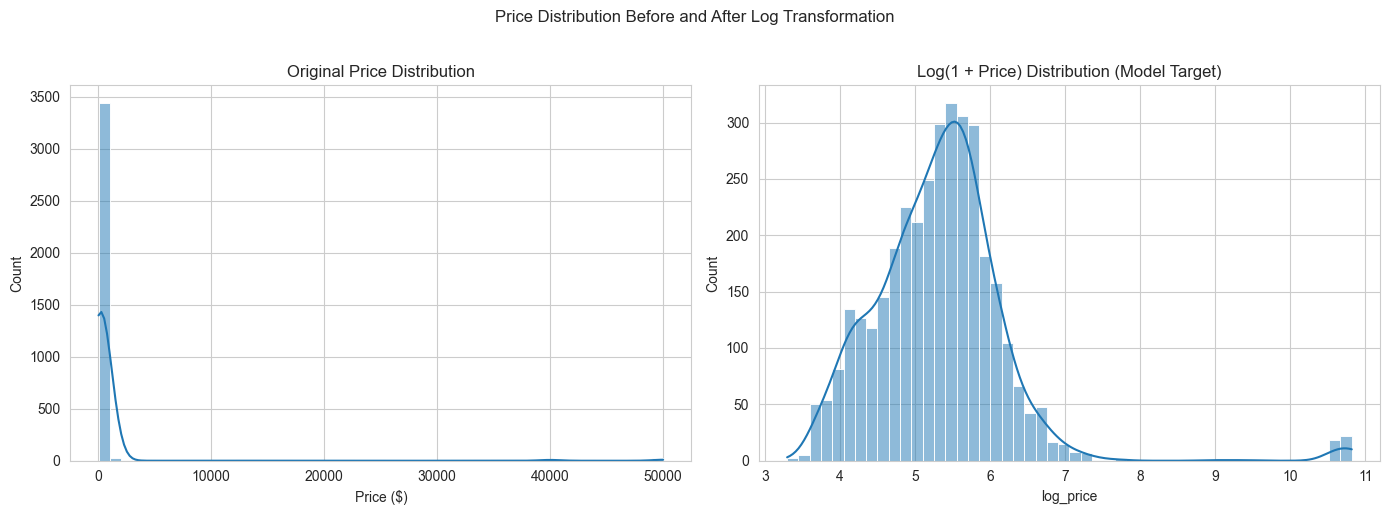

Price skewness:     9.30
log_price skewness: 2.17


In [75]:
#convert price to numeric
df["price"] = (
    df["price"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
)

df["price"] = pd.to_numeric(df["price"], errors="coerce")

# drop rows where price couldn't be converted
df = df.dropna(subset=["price"])

# Create log-transformed price
df["log_price"] = np.log1p(df["price"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original price
sns.histplot(df["price"], bins=50, kde=True, ax=axes[0])
axes[0].set_title("Original Price Distribution")
axes[0].set_xlabel("Price ($)")
axes[0].set_ylabel("Count")

sns.histplot(df["log_price"], bins=50, kde=True, ax=axes[1])
axes[1].set_title("Log(1 + Price) Distribution (Model Target)")
axes[1].set_xlabel("log_price")
axes[1].set_ylabel("Count")

plt.suptitle("Price Distribution Before and After Log Transformation", y=1.02)
os.makedirs("plots", exist_ok=True)
fig.savefig("plots/price_distribution_orginal.png", dpi=150, bbox_inches="tight")
plt.tight_layout()
plt.show()

print(f"Price skewness:     {df['price'].skew():.2f}")
print(f"log_price skewness: {df['log_price'].skew():.2f}")

IQR-based upper threshold: $903.00
After removing outliers: (3416, 65)


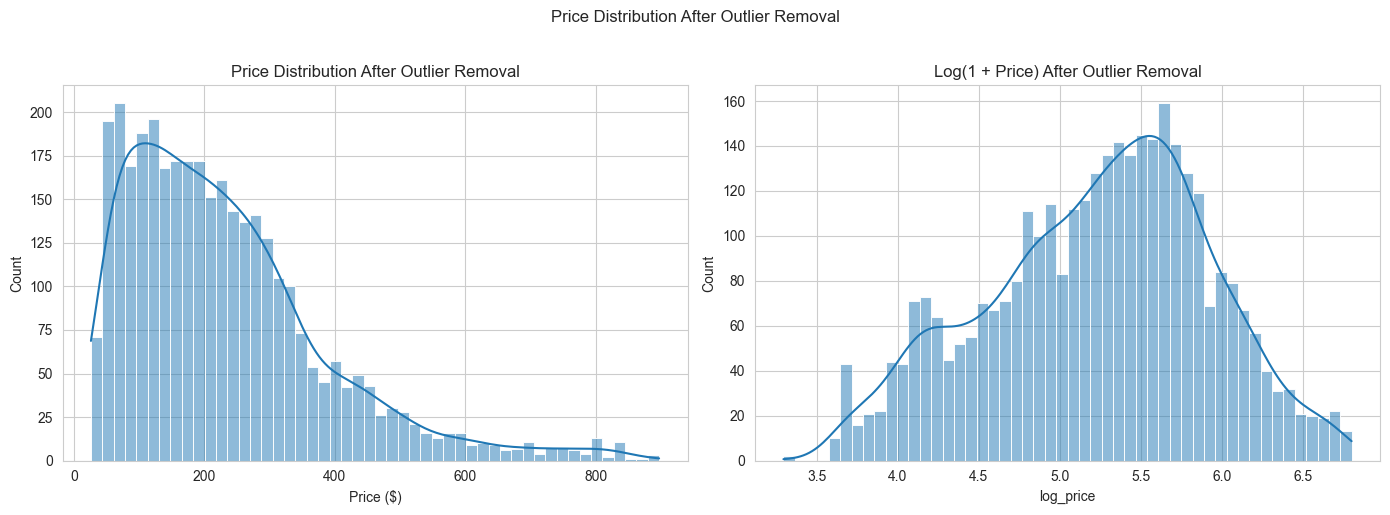

Price skewness:     1.34
log_price skewness: -0.25


In [76]:
# IQR-based outlier removal
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)
IQR = Q3 - Q1

upper = Q3 + 3 * IQR

# Filter out extreme outliers
df = df[df["price"] <= upper].copy()

print(f"IQR-based upper threshold: ${upper:.2f}")
print("After removing outliers:", df.shape)

# Recreate log_price
df["log_price"] = np.log1p(df["price"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df["price"], bins=50, kde=True, ax=axes[0])
axes[0].set_title("Price Distribution After Outlier Removal")
axes[0].set_xlabel("Price ($)")
axes[0].set_ylabel("Count")

# Cleaned log price
sns.histplot(df["log_price"], bins=50, kde=True, ax=axes[1])
axes[1].set_title("Log(1 + Price) After Outlier Removal")
axes[1].set_xlabel("log_price")
axes[1].set_ylabel("Count")

plt.suptitle("Price Distribution After Outlier Removal", y=1.02)
plt.tight_layout()
os.makedirs("plots", exist_ok=True)
fig.savefig("plots/price_distribution_after_outlier_removal.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Price skewness:     {df['price'].skew():.2f}")
print(f"log_price skewness: {df['log_price'].skew():.2f}")


### 1.3 Host Related

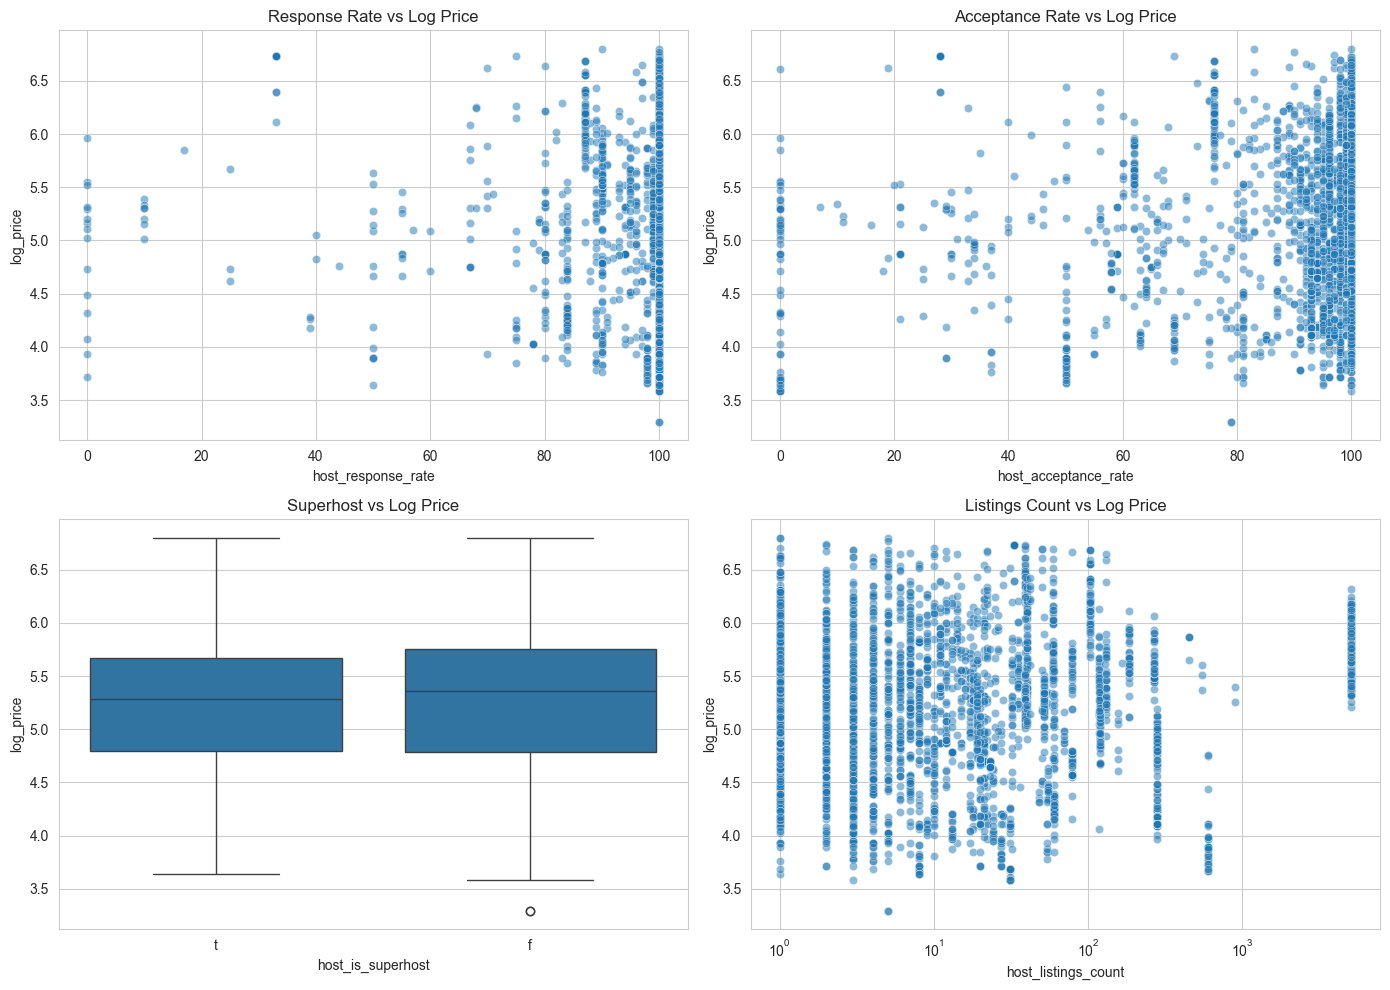

In [77]:
# Convert percentage strings to float
df["host_response_rate"] = (
    df["host_response_rate"]
    .astype(str)
    .str.rstrip("%")
)
df["host_response_rate"] = pd.to_numeric(
    df["host_response_rate"], errors="coerce"
)

df["host_acceptance_rate"] = (
    df["host_acceptance_rate"]
    .astype(str)
    .str.rstrip("%")
)
df["host_acceptance_rate"] = pd.to_numeric(
    df["host_acceptance_rate"], errors="coerce"
)

# Ensure numeric
df["host_listings_count"] = pd.to_numeric(
    df["host_listings_count"], errors="coerce"
)

# Plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Response rate
sns.scatterplot(
    ax=axes[0,0],
    x="host_response_rate",
    y="log_price",
    data=df,
    alpha=0.5
)
axes[0,0].set_title("Response Rate vs Log Price")

# Acceptance rate
sns.scatterplot(
    ax=axes[0,1],
    x="host_acceptance_rate",
    y="log_price",
    data=df,
    alpha=0.5
)
axes[0,1].set_title("Acceptance Rate vs Log Price")

# Superhost
sns.boxplot(
    ax=axes[1,0],
    x="host_is_superhost",
    y="log_price",
    data=df
)
axes[1,0].set_title("Superhost vs Log Price")

# Listings count
sns.scatterplot(
    ax=axes[1,1],
    x="host_listings_count",
    y="log_price",
    data=df,
    alpha=0.5
)
axes[1,1].set_xscale("log")
axes[1,1].set_title("Listings Count vs Log Price")

plt.tight_layout()
os.makedirs("plots", exist_ok=True)
fig.savefig("plots/host_related.png", dpi=150, bbox_inches="tight")
plt.show()

Most host related numerical features, such as response rate and acceptance rate, show weak relationships with price. However, superhost status exhibits a modest upward shift in price distribution.

In [78]:
# Convert host_is_superhost to numeric
df["host_is_superhost"] = (
    df["host_is_superhost"]
    .map({"t": 1, "f": 0})
    .fillna(0)
    .astype(int)
)

# Drop host-related columns except superhost
host_drop_cols = [
    "host_id",
    "host_url",
    "host_name",
    "host_since",
    "host_location",
    "host_about",
    "host_response_time",
    "host_response_rate",
    "host_acceptance_rate",
    "host_thumbnail_url",
    "host_picture_url",
    "host_neighbourhood",
    "host_listings_count",
    "host_total_listings_count",
    "host_verifications",
    "host_has_profile_pic",
    "host_identity_verified",
    "calculated_host_listings_count",
    "calculated_host_listings_count_entire_homes",
    "calculated_host_listings_count_private_rooms",
    "calculated_host_listings_count_shared_rooms",
]

df = df.drop(columns=host_drop_cols, errors="ignore")

print("Shape after removing host features:", df.shape)
print(df["host_is_superhost"].value_counts(dropna=False))

Shape after removing host features: (3416, 44)
host_is_superhost
0    2187
1    1229
Name: count, dtype: int64


### 1.4 min/max nights

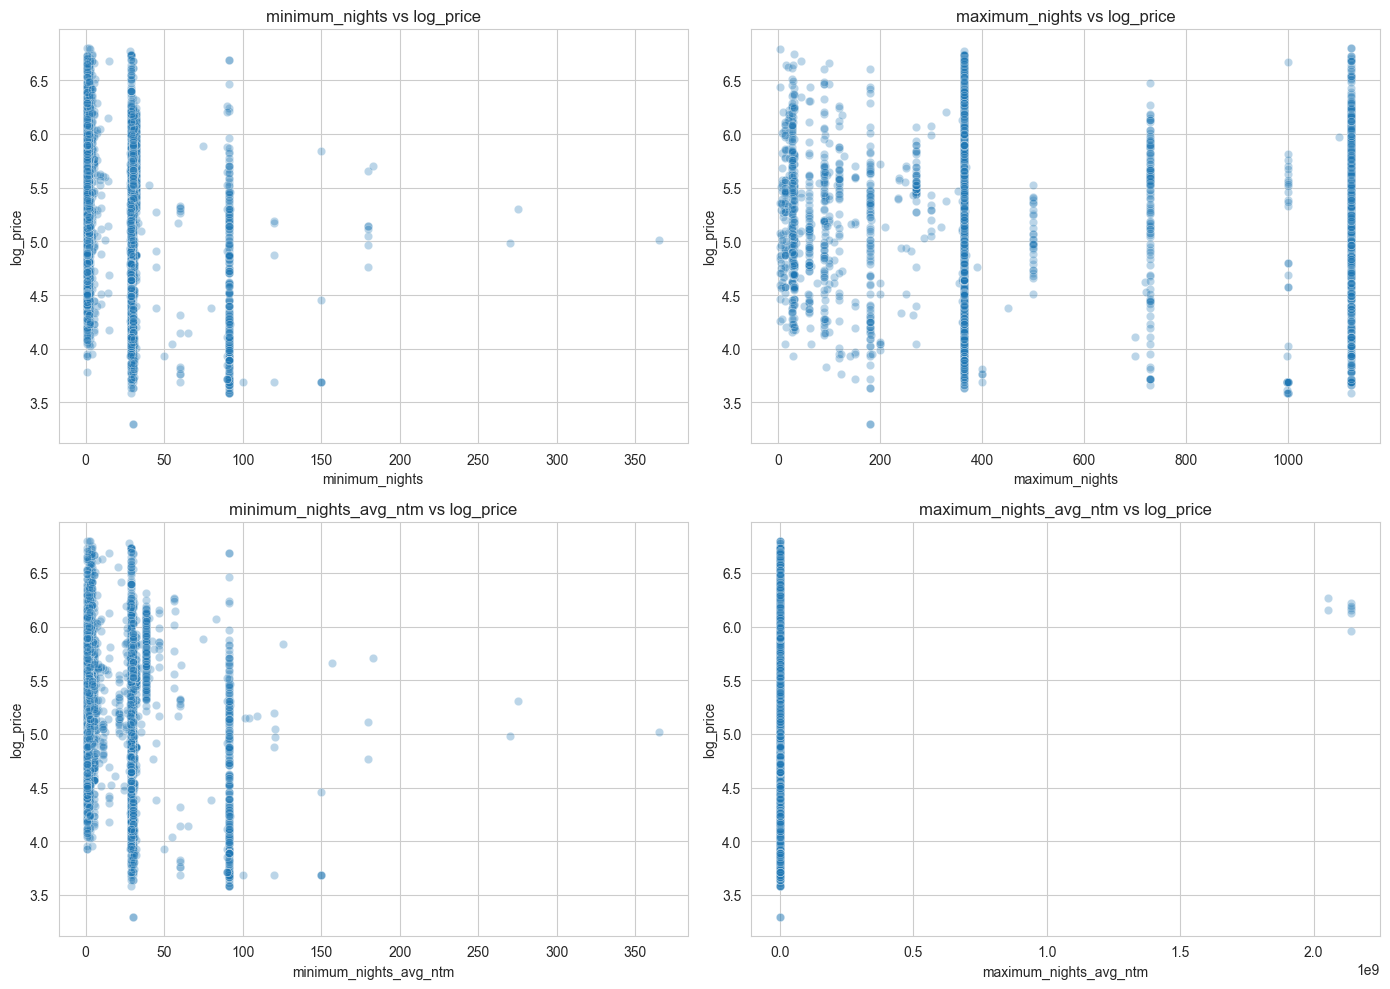

In [79]:
cols = [
    "minimum_nights",
    "maximum_nights",
    "minimum_nights_avg_ntm",
    "maximum_nights_avg_ntm"
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, col in enumerate(cols):
    ax = axes[i // 2, i % 2]
    sns.scatterplot(data=df, x=col, y="log_price", alpha=0.3, ax=ax)
    ax.set_title(f"{col} vs log_price")

plt.tight_layout()
os.makedirs("plots", exist_ok=True)
fig.savefig("plots/min_max_nights.png", dpi=150, bbox_inches="tight")
plt.show()

In [80]:
threshold = df["log_price"].quantile(0.75)
df["is_high_price"] = (df["log_price"] >= threshold).astype(int)
df["is_short_stay"] = (df["minimum_nights"] <= 2).astype(int)
df.groupby("is_short_stay")["is_high_price"].mean()

is_short_stay
0    0.240140
1    0.263977
Name: is_high_price, dtype: float64

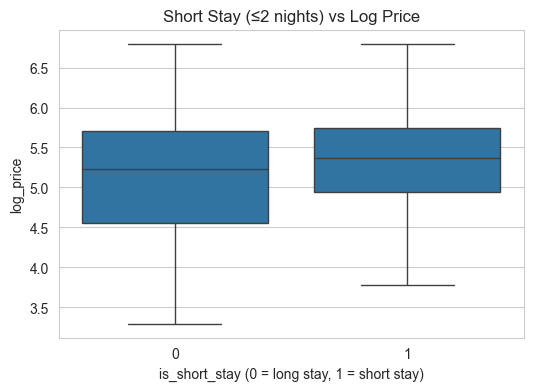

In [81]:
plt.figure(figsize=(6, 4))

sns.boxplot(
    x="is_short_stay",
    y="log_price",
    data=df
)

plt.title("Short Stay (≤2 nights) vs Log Price")
plt.xlabel("is_short_stay (0 = long stay, 1 = short stay)")
plt.ylabel("log_price")

os.makedirs("plots", exist_ok=True)
plt.savefig("plots/is_short_stay.png", dpi=150, bbox_inches="tight")

plt.show()

The minimum and maximum night features showed no clear relationship with price in scatter plots and had near zero correlation, indicating they provide little predictive value. Additionally, the calendar derived night variables were highly redundant and introduced noise without adding new information. Instead, a binary feature is_short_stay (≤2 nights) was retained, as it captures a meaningful behavioral pattern and shows a slightly higher likelihood of high priced listings.

In [82]:
night_drop_cols = [
    "minimum_nights",
    "maximum_nights",
    "minimum_minimum_nights",
    "maximum_minimum_nights",
    "minimum_maximum_nights",
    "maximum_maximum_nights",
    "minimum_nights_avg_ntm",
    "maximum_nights_avg_ntm",
]

df = df.drop(columns=night_drop_cols, errors="ignore")

print("Shape after dropping night features:", df.shape)
print(df["is_short_stay"].value_counts())

Shape after dropping night features: (3416, 38)
is_short_stay
0    2003
1    1413
Name: count, dtype: int64


### 1.5 Availability



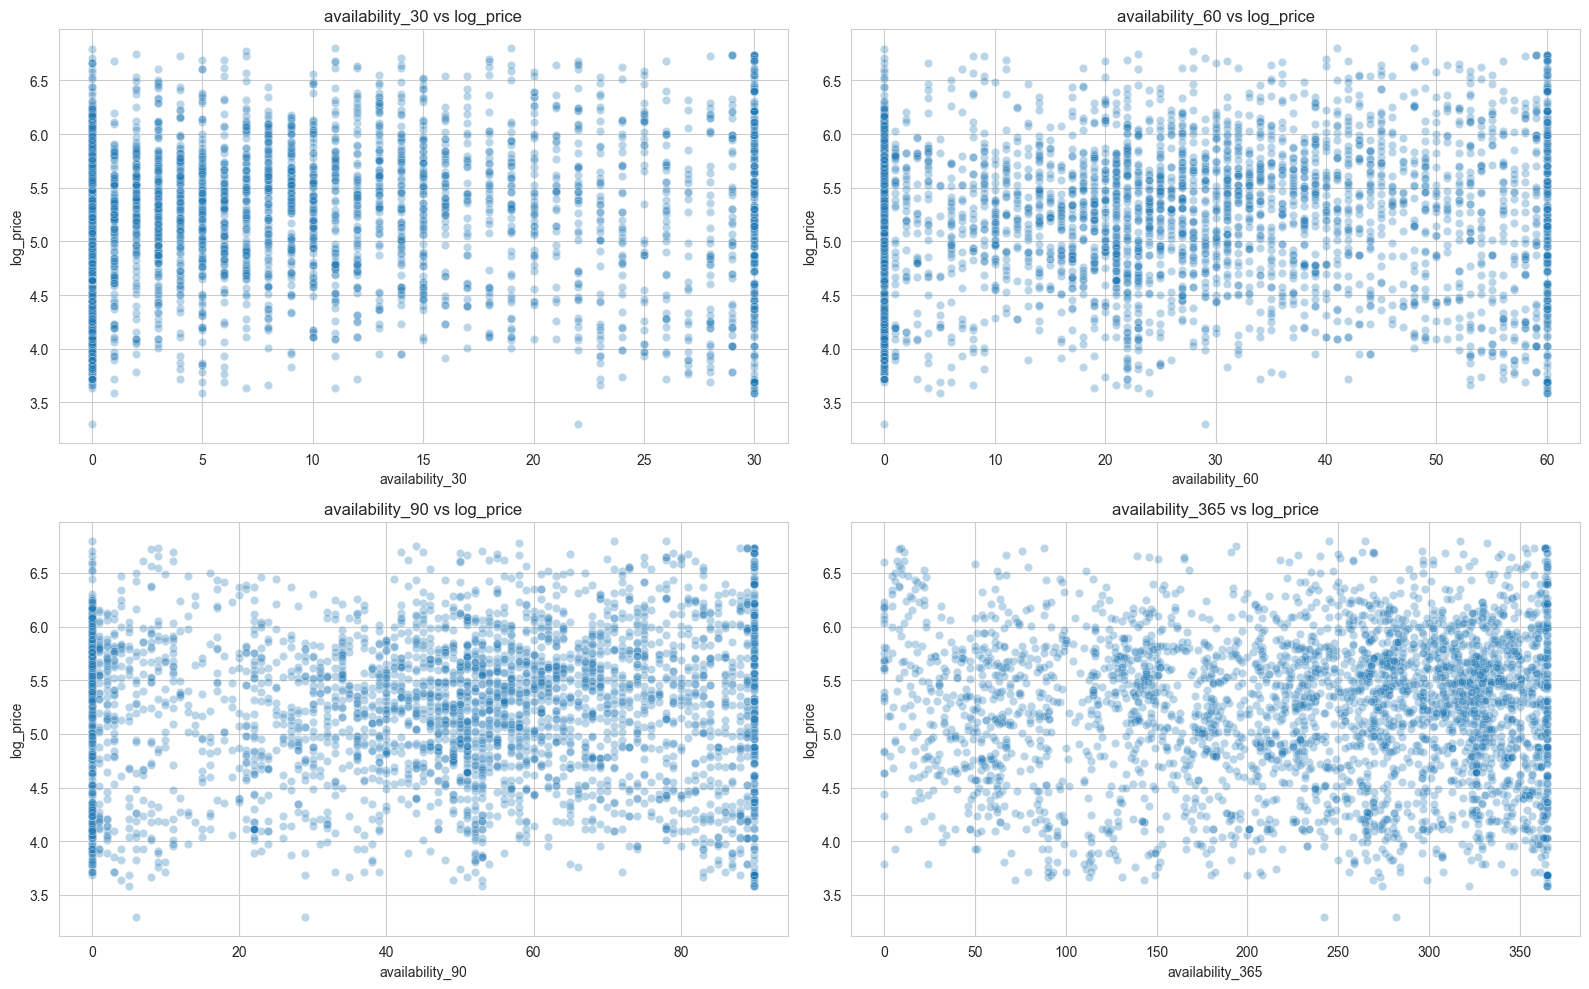

In [83]:
cols = [
    "availability_30",
    "availability_60",
    "availability_90",
    "availability_365",
]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for i, col in enumerate(cols):
    ax = axes[i // 2, i % 2]
    sns.scatterplot(data=df, x=col, y="log_price", alpha=0.3, ax=ax)
    ax.set_title(f"{col} vs log_price")

plt.tight_layout()
os.makedirs("plots", exist_ok=True)
fig.savefig("plots/availability.png", dpi=150, bbox_inches="tight")
plt.show()

In [84]:
availability_drop = [
    "has_availability",
    "availability_30",
    "availability_60",
    "availability_90",
    "availability_eoy"
]

df = df.drop(columns=availability_drop, errors="ignore")
print("Shape after dropping availability features:", df.shape)

Shape after dropping availability features: (3416, 33)


### 1.6 Reviews

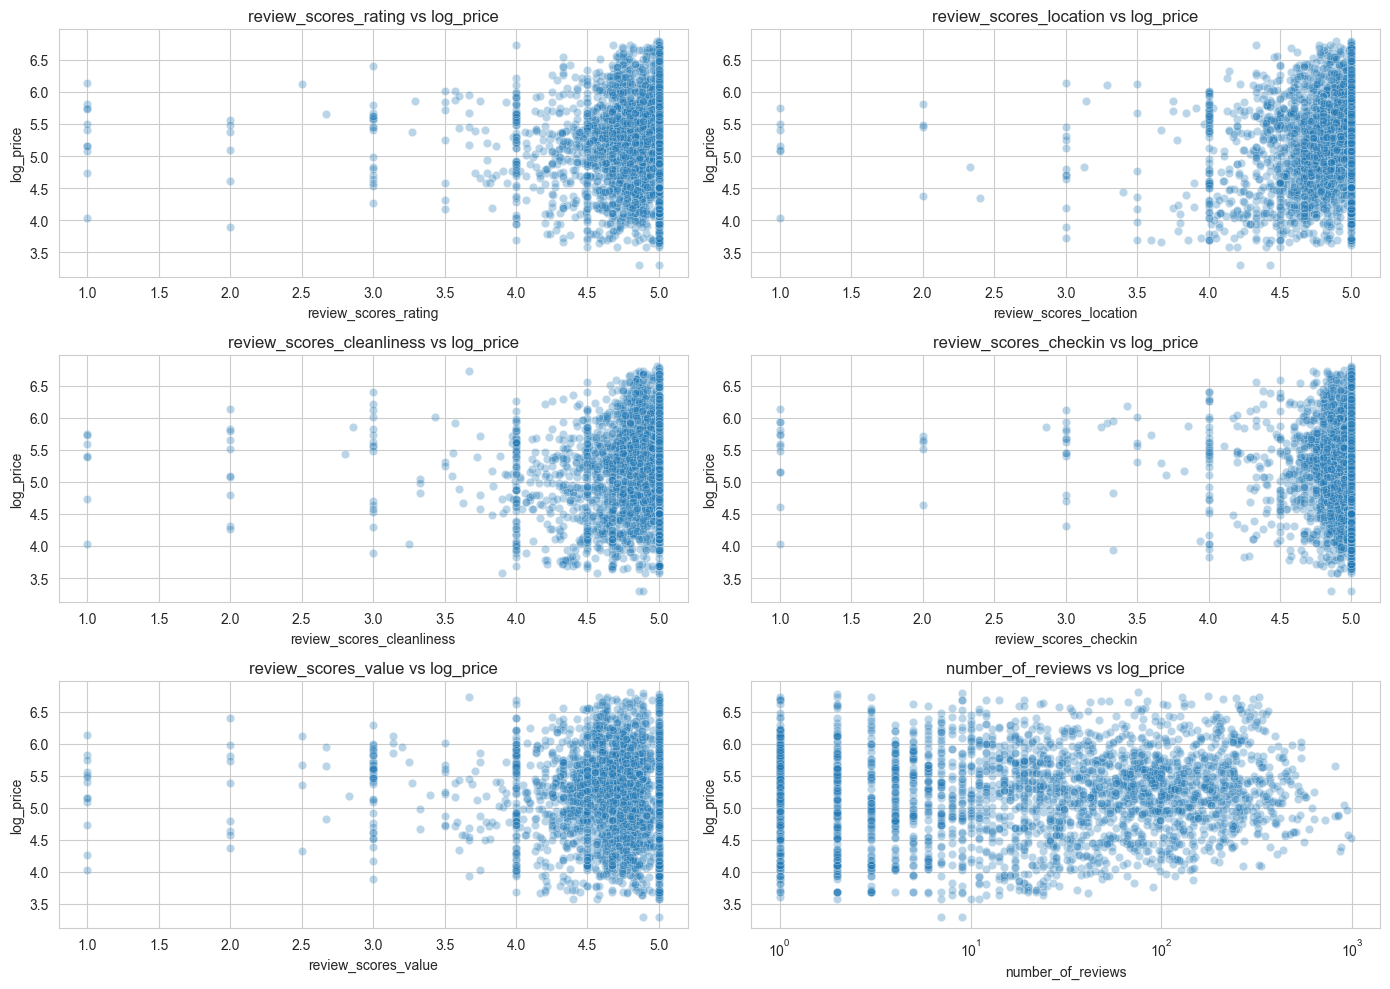

In [85]:
cols = [
    "review_scores_rating",
    "review_scores_location",
    "review_scores_cleanliness",
    "review_scores_checkin",
    "review_scores_value",
    "number_of_reviews"
]

fig, axes = plt.subplots(3, 2, figsize=(14, 10))

for i, col in enumerate(cols):
    ax = axes[i // 2, i % 2]

    plot_df = df[[col, "log_price"]].dropna()

    sns.scatterplot(
        data=plot_df,
        x=col,
        y="log_price",
        alpha=0.3,
        ax=ax
    )

    ax.set_title(f"{col} vs log_price")

    if col == "number_of_reviews":
        ax.set_xscale("log")

plt.tight_layout()
os.makedirs("plots", exist_ok=True)
fig.savefig("plots/reviews.png", dpi=150, bbox_inches="tight")
plt.show()

All review score variables showed very limited spread, with most listings clustered between 4 and 5.
Their relationships with log_price were weak and visually very similar, suggesting strong redundancy
and limited predictive value. In contrast, number_of_reviews had a wider distribution and may capture
listing popularity or maturity, so it was retained.

In [86]:
# Keep review_scores_rating and number_of_reviews
review_drop = [
    "review_scores_accuracy",
    "review_scores_rating",
    "review_scores_cleanliness",
    "review_scores_checkin",
    "review_scores_communication",
    "review_scores_location",
    "review_scores_value",
    "number_of_reviews_ltm",
    "number_of_reviews_l30d",
    "number_of_reviews_ly",
    "first_review",
    "last_review",
    "reviews_per_month"
]

df = df.drop(columns=review_drop, errors="ignore")
print("Shape after dropping review features:", df.shape)

Shape after dropping review features: (3416, 20)


### 1.7 Propety and Room type




In [87]:
print(df["room_type"].value_counts())
print()
print(df["property_type"].value_counts())

room_type
Entire home/apt    2443
Private room        965
Hotel room            5
Shared room           3
Name: count, dtype: int64

property_type
Entire rental unit                    1862
Private room in rental unit            463
Private room in home                   292
Entire condo                           227
Entire home                            170
Entire serviced apartment               64
Entire guest suite                      62
Private room in condo                   53
Room in hotel                           44
Private room in townhouse               38
Entire townhouse                        22
Private room in bed and breakfast       22
Room in boutique hotel                  21
Entire loft                             18
Private room in serviced apartment      12
Private room in guest suite             11
Boat                                     7
Private room                             7
Houseboat                                4
Entire guesthouse                   

In [88]:
# property_type: 30+ categories and many with <10 samples
# it mixes room type and property structure together
# ignore:Entire, private room, shared room;
# keep: apartment,house, cando, twonhouse, hotel, others

def clean_property_type(x):
    x = x.lower()

    if "rental unit" in x or "apartment" in x:
        return "apartment"
    elif "home" in x or "house" in x or "vacation home" in x:
        return "house"
    elif "condo" in x:
        return "condo"
    elif "townhouse" in x:
        return "townhouse"
    elif "hotel" in x or "boutique hotel" in x:
        return "hotel"
    elif "loft" in x:
        return "loft"
    elif "guest suite" in x or "guesthouse" in x:
        return "guest_space"
    elif "serviced apartment" in x:
        return "serviced_apartment"
    else:
        return "other"

df["property_type_clean"] = df["property_type"].apply(clean_property_type)

print(df["property_type_clean"].value_counts())

property_type_clean
apartment      2403
house           532
condo           281
guest_space      73
hotel            65
other            43
loft             19
Name: count, dtype: int64


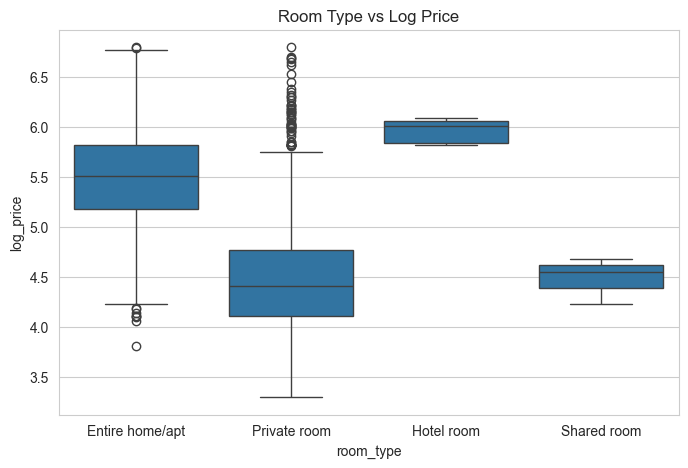

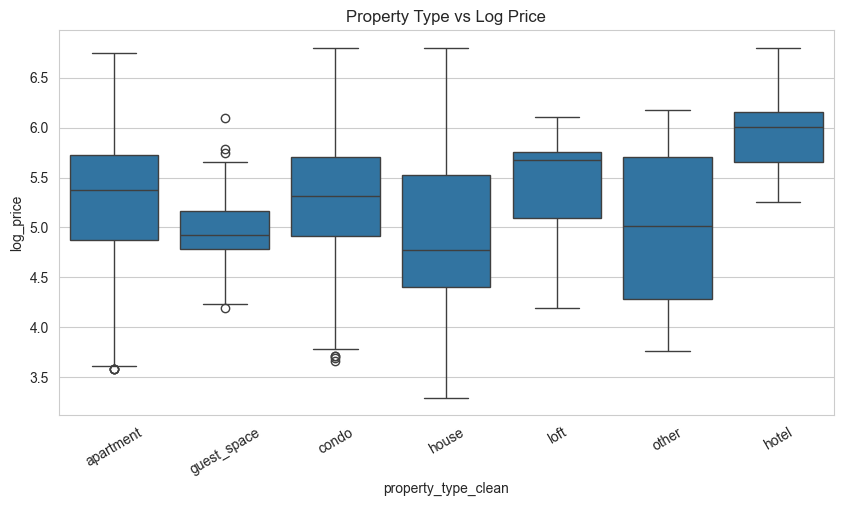

In [ ]:
os.makedirs("plots", exist_ok=True)

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="room_type", y="log_price")
plt.title("Room Type vs Log Price")
plt.savefig("plots/room_type_vs_price.png", dpi=150, bbox_inches="tight")
plt.show()

plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="property_type_clean", y="log_price")
plt.title("Property Type vs Log Price")
plt.xticks(rotation=30)
plt.savefig("plots/property_type_vs_price.png", dpi=150, bbox_inches="tight")
plt.show()

In [56]:
# drop original columns
df = df.drop(columns=["property_type"], errors="ignore")
print("Shape after feature room and property type:", df.shape)

Shape after feature room and property type: (3416, 20)


### 1.8 Bathroom

In [37]:
print(df["bathrooms"].value_counts().sort_index())
print()
print(df["bathrooms_text"].value_counts() )

bathrooms
0.0      50
0.5       4
1.0    2466
1.5     176
2.0     589
2.5      59
3.0      46
3.5       7
4.0       5
4.5       3
5.0       3
5.5       1
6.0       2
7.0       1
Name: count, dtype: int64

bathrooms_text
1 bath               1843
2 baths               464
1 shared bath         428
1 private bath        195
2 shared baths        125
1.5 baths             117
1.5 shared baths       59
2.5 baths              51
0 shared baths         40
3 baths                38
0 baths                10
2.5 shared baths        8
3 shared baths          8
3.5 baths               7
4 baths                 5
4.5 baths               3
Half-bath               2
6 baths                 2
5 shared baths          2
Private half-bath       1
Shared half-bath        1
5 baths                 1
5.5 baths               1
7 baths                 1
Name: count, dtype: int64


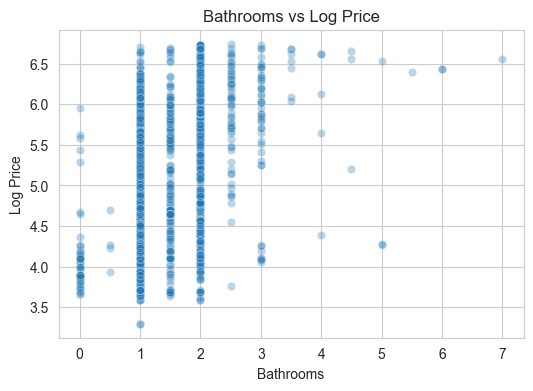

In [38]:
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x="bathrooms", y="log_price", alpha=0.3)

plt.title("Bathrooms vs Log Price")
plt.xlabel("Bathrooms")
plt.ylabel("Log Price")

os.makedirs("plots", exist_ok=True)
fig.savefig("plots/bathroom_vs_price.png", dpi=150, bbox_inches="tight")
plt.show()

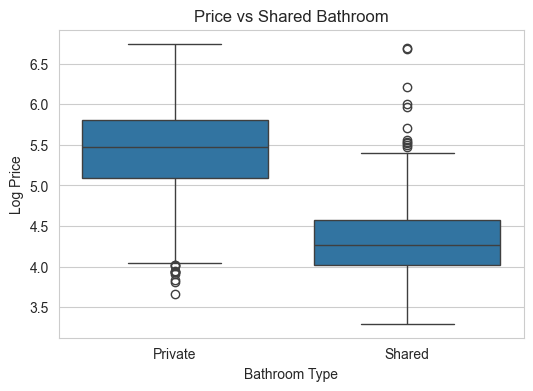

                count      mean    median
is_shared_bath                           
0                2741  5.453666  5.472271
1                 671  4.317993  4.262680
Shape after feature bathroom: (3412, 20)


In [39]:
# Create shared bathroom indicator
bath_text = df["bathrooms_text"].astype("string").str.lower()
df["is_shared_bath"] = bath_text.str.contains("shared", na=False).astype(int)

plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x="is_shared_bath", y="log_price")

plt.title("Price vs Shared Bathroom")
plt.xlabel("Bathroom Type")
plt.ylabel("Log Price")
plt.xticks([0, 1], ["Private", "Shared"])

os.makedirs("plots", exist_ok=True)
fig.savefig("plots/shared_bathroom.png", dpi=150, bbox_inches="tight")
plt.show()

print(df.groupby("is_shared_bath")["log_price"].agg(["count", "mean", "median"]))

df = df.drop(columns=["bathrooms_text"], errors="ignore")
print("Shape after feature bathroom:", df.shape)


### 1.9 Neighborhood


In [40]:
# neighborhood_overview (text, lots of missing)
# neighbourhood (some missing)
drop_neigh_cols = [
    "neighborhood_overview",
    "neighbourhood"
]

df = df.drop(columns=drop_neigh_cols, errors="ignore")

print("Shape after dropping unncessary neigborhood ", df.shape)
print()
print("neighbourhood_cleansed unique:", df["neighbourhood_cleansed"].nunique())
print()
print(df["neighbourhood_cleansed"].value_counts())

Shape after dropping unncessary neigborhood  (3412, 18)

neighbourhood_cleansed unique: 25

neighbourhood_cleansed
Dorchester                 471
Back Bay                   298
Downtown                   272
Roxbury                    255
Brighton                   234
South End                  203
Beacon Hill                194
Fenway                     188
Jamaica Plain              177
East Boston                165
South Boston               139
Allston                    122
North End                   89
Roslindale                  85
West Roxbury                72
Mission Hill                69
Hyde Park                   65
Bay Village                 62
Charlestown                 60
Mattapan                    60
South Boston Waterfront     55
West End                    38
Chinatown                   29
Leather District             6
Longwood Medical Area        4
Name: count, dtype: int64


In [41]:
# combined with their corresponding larger neighborhoods based on geographic proximity and domain knowledge.
neigh_map = {
    "South Boston Waterfront": "South Boston",
    "Leather District": "Downtown",
    "Longwood Medical Area": "Fenway"
}

df["neighbourhood_cleaned"] = df["neighbourhood_cleansed"].replace(neigh_map)

df = df.drop(columns="neighbourhood_cleansed", errors="ignore")

print("Shape after dropping unncessary neigborhood ", df.shape)
print()

print(df["neighbourhood_cleaned"].value_counts())
print("Unique after cleaning:", df["neighbourhood_cleaned"].nunique())

Shape after dropping unncessary neigborhood  (3412, 18)

neighbourhood_cleaned
Dorchester       471
Back Bay         298
Downtown         278
Roxbury          255
Brighton         234
South End        203
Beacon Hill      194
South Boston     194
Fenway           192
Jamaica Plain    177
East Boston      165
Allston          122
North End         89
Roslindale        85
West Roxbury      72
Mission Hill      69
Hyde Park         65
Bay Village       62
Charlestown       60
Mattapan          60
West End          38
Chinatown         29
Name: count, dtype: int64
Unique after cleaning: 22


In [42]:
neigh_summary = (
    df.groupby("neighbourhood_cleaned")
      .agg(
          listing_count=("neighbourhood_cleaned", "size"),
          mean_price=("price", "mean"),
          mean_log_price=("log_price", "mean")
      )
      .sort_values("listing_count", ascending=False)
      .reset_index()
)

print(neigh_summary)

   neighbourhood_cleaned  listing_count  mean_price  mean_log_price
0             Dorchester            471  175.016985        4.877932
1               Back Bay            298  312.483221        5.656392
2               Downtown            278  359.830935        5.805265
3                Roxbury            255  186.862745        4.942643
4               Brighton            234  182.576923        5.044762
5              South End            203  262.896552        5.477127
6            Beacon Hill            194  172.030928        4.991719
7           South Boston            194  270.747423        5.437287
8                 Fenway            192  262.963542        5.489229
9          Jamaica Plain            177  262.062147        5.331650
10           East Boston            165  183.436364        5.061968
11               Allston            122  186.262295        4.950465
12             North End             89  280.044944        5.472583
13            Roslindale             85  160.364

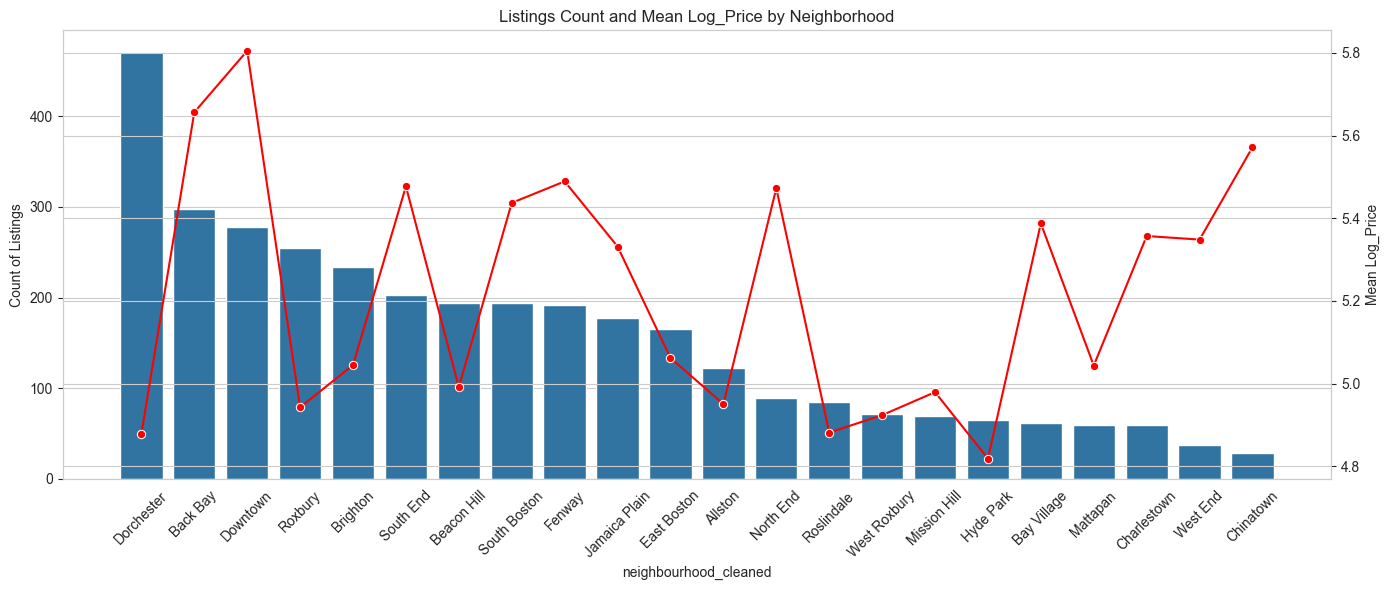

In [43]:
fig, ax1 = plt.subplots(figsize=(14, 6))

sns.barplot(
    data=neigh_summary,
    x="neighbourhood_cleaned",
    y="listing_count",
    ax=ax1
)
ax1.set_ylabel("Count of Listings")
ax1.tick_params(axis="x", rotation=45)

ax2 = ax1.twinx()

sns.lineplot(
    data=neigh_summary,
    x="neighbourhood_cleaned",
    y="mean_log_price",
    ax=ax2,
    marker="o",
    color="red"
)
ax2.set_ylabel("Mean Log_Price")

plt.title("Listings Count and Mean Log_Price by Neighborhood")
plt.tight_layout()
os.makedirs("plots", exist_ok=True)
fig.savefig("plots/neighborhood_count_meanPrice.png", dpi=150, bbox_inches="tight")
plt.show()


## 2. Feature Engineering

### 2.1 Amenities

In [44]:
# Clean and split amenities
amenities_series = (
    df["amenities"]
    .astype(str)
    .str.strip("{}")
    .str.split(",")
)

# Flatten into one column
amenities_exploded = amenities_series.explode().str.strip().str.lower()

top_amenities = amenities_exploded.value_counts().head(20)

print("Top 20 most common amenities:")
print(top_amenities)

Top 20 most common amenities:
amenities
"carbon monoxide alarm"      3258
"smoke alarm"                3184
"wifi"                       3072
"hot water"]                 3057
"hangers"                    2967
"iron"                       2838
"essentials"                 2800
"hair dryer"                 2796
"kitchen"                    2775
"cooking basics"             2760
"bed linens"                 2751
"microwave"                  2733
"refrigerator"               2659
"shampoo"                    2534
"dishes and silverware"      2513
"self check-in"              2378
"air conditioning"           2222
"dedicated workspace"        2143
"fire extinguisher"          2104
"long term stays allowed"    2079
Name: count, dtype: int64


In [ ]:
# binary flags
amenity_flags = {
    "has_wifi": r"wifi|wi-fi|wireless",
    "has_parking": r"parking|garage|free street parking",
    "has_kitchen": r"kitchen",
    "has_ac": r"air conditioning|ac|central air",
    "has_self_checkin": r"self check-in",
    "has_pet_allowed" : r"pets allowed|pet allowed",
}
for col, pattern in amenity_flags.items():
    df[col] = df["amenities"].str.contains(
        pattern, case=False
    ).astype(int)

df = df.drop(columns=["amenities"], errors="ignore")


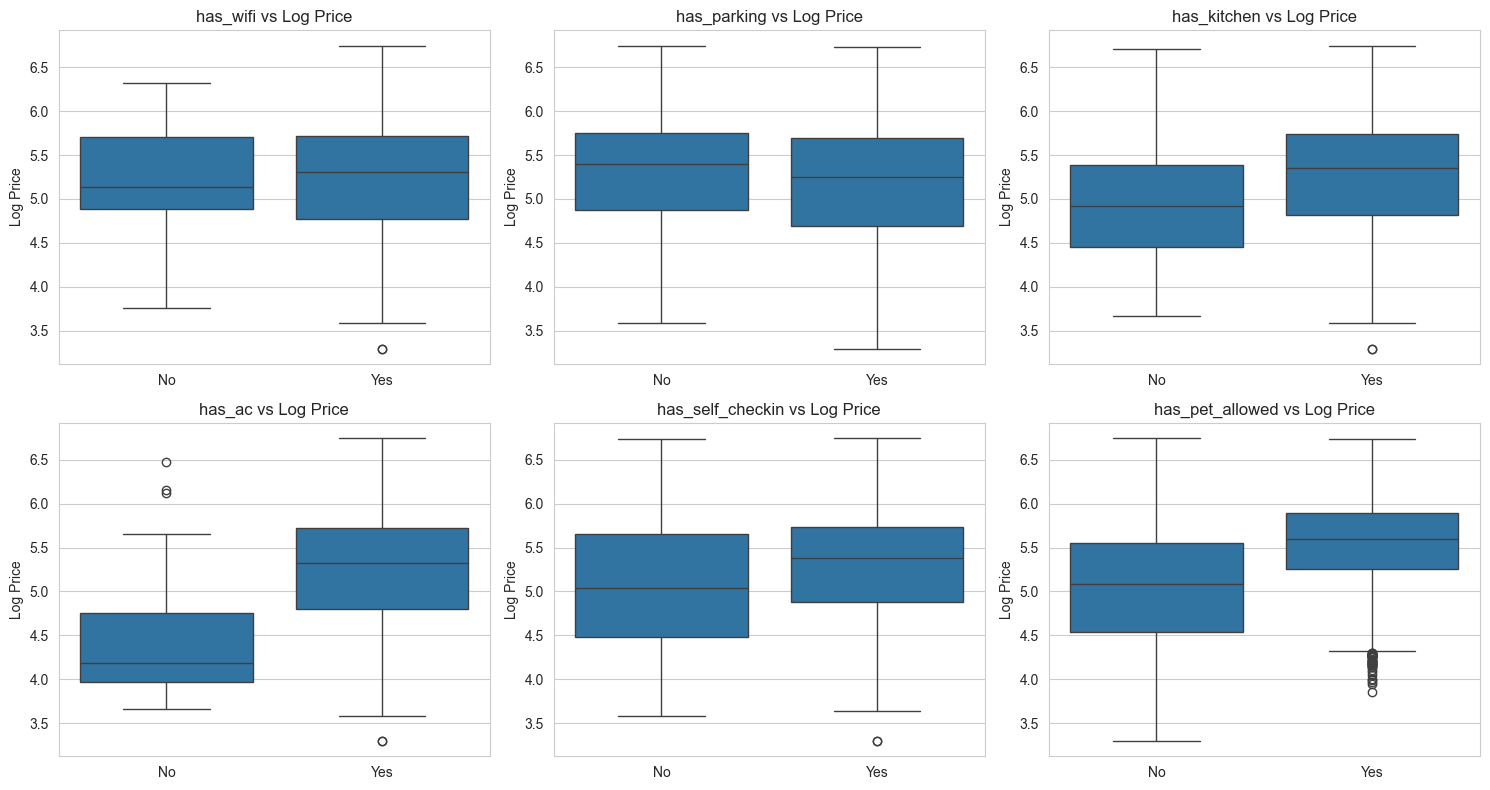

In [46]:
cols = list(amenity_flags.keys())

n = len(cols)
rows = (n + 2) // 3

fig, axes = plt.subplots(rows, 3, figsize=(15, 4 * rows))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.boxplot(data=df, x=col, y="log_price", ax=axes[i])

    axes[i].set_title(f"{col} vs Log Price")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Log Price")
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(["No", "Yes"])

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
os.makedirs("plots", exist_ok=True)
fig.savefig("plots/amenity.png", dpi=150, bbox_inches="tight")
plt.show()

In [47]:
for col in amenity_flags.keys():
    print(f"\n{col}:")
    print(df.groupby(col)["log_price"].agg(["count", "mean", "median"]))


has_wifi:
          count      mean    median
has_wifi                           
0            21  5.197249  5.141664
1          3391  5.230531  5.303305

has_parking:
             count      mean    median
has_parking                           
0             1262  5.308577  5.402677
1             2150  5.184395  5.249649

has_kitchen:
             count      mean    median
has_kitchen                           
0              360  4.941517  4.919981
1             3052  5.264393  5.347108

has_ac:
        count      mean    median
has_ac                           
0          82  4.405477  4.182021
1        3330  5.250638  5.323010

has_self_checkin:
                  count      mean    median
has_self_checkin                           
0                  1033  5.074407  5.043425
1                  2379  5.298029  5.375278

has_pet_allowed:
                 count      mean    median
has_pet_allowed                           
0                 2186  5.055024  5.081404
1                 

### 2.2 Geographic clustering

In [48]:
# KMeans
X_geo = df[["latitude", "longitude"]]

# find optimal k using silhouette score
print("Silhouette scores by k:")
for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_geo)
    print(f"k={k}: {silhouette_score(X_geo, labels):.4f}")

# use k=6 (highest silhouette score)
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
df["geo_cluster"] = kmeans.fit_predict(X_geo)

# recode names after seeing the graphs
cluster_label_map = {
    0: "Mid Dorchester",
    1: "Kenmore / Fenway",
    2: "Allston / Brighton",
    3: "Roslindale",
    4: "East Boston",
    5: "Chinatown / Downtown",
}

df["geo_area"] = df["geo_cluster"].map(cluster_label_map)


Silhouette scores by k:
k=2: 0.4640
k=3: 0.4410
k=4: 0.4622
k=5: 0.4700
k=6: 0.4731
k=7: 0.4710


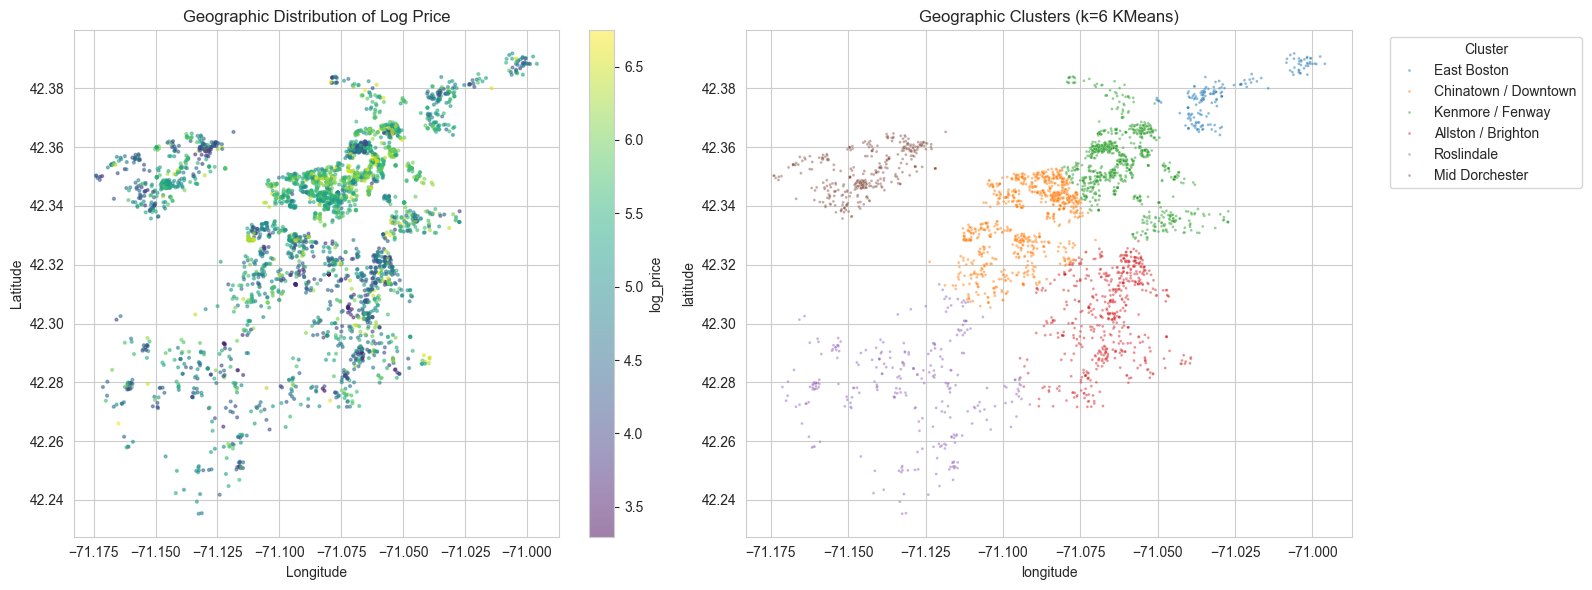

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# price heat-map
sc = axes[0].scatter(
    df["longitude"], df["latitude"],
    c=df["log_price"],
    cmap="viridis",
    alpha=0.5,
    s=4
)
plt.colorbar(sc, ax=axes[0], label="log_price")
axes[0].set_title("Geographic Distribution of Log Price")
axes[0].set_xlabel("Longitude"); axes[0].set_ylabel("Latitude")

# KMeans clusters
sns.scatterplot(
    data=df,
    x="longitude",
    y="latitude",
    hue="geo_area",
    palette="tab10",
    alpha=0.5,
    s=4,
    ax=axes[1]
)
axes[1].set_title("Geographic Clusters (k=6 KMeans)")
axes[1].legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
os.makedirs("plots", exist_ok=True)
fig.savefig("plots/KMeans_geographic.png", dpi=150, bbox_inches="tight")
plt.show()

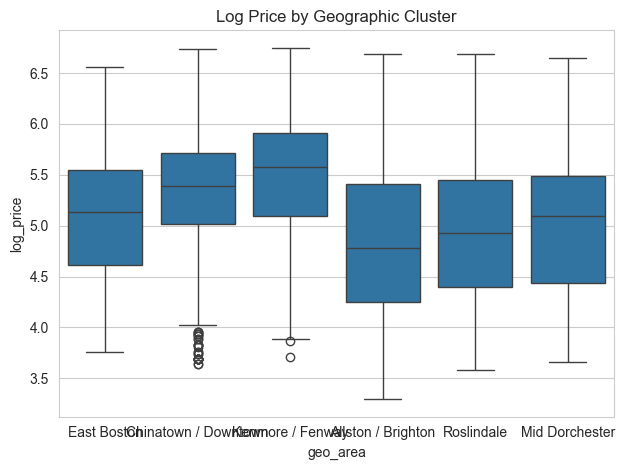

In [51]:
# price variation across geographic clusters
sns.boxplot(data=df, x="geo_area", y="log_price")
plt.title("Log Price by Geographic Cluster")
plt.tight_layout()
os.makedirs("plots", exist_ok=True)
fig.savefig("plots/Price_by_Geographic_Cluster.png", dpi=150, bbox_inches="tight")
plt.show()


## 3. Correction Matrix

In [52]:
# Correlation matrix for key numeric features
corr_cols = [
    "log_price",
    "host_is_superhost",
    "latitude",
    "longitude",
    "accommodates",
    "bathrooms",
    "bedrooms",
    "beds",
    "availability_365",
    "number_of_reviews",
    "is_shared_bath",
]
missing = df[corr_cols].isnull().sum()
print("Missing values per column:\n", missing)

df_corr = df[corr_cols].dropna()

print("Shape before:", df[corr_cols].shape)
print("Shape after dropna:", df_corr.shape)

Missing values per column:
 log_price            0
host_is_superhost    0
latitude             0
longitude            0
accommodates         0
bathrooms            0
bedrooms             0
beds                 1
availability_365     0
number_of_reviews    0
is_shared_bath       0
dtype: int64
Shape before: (3412, 11)
Shape after dropna: (3411, 11)


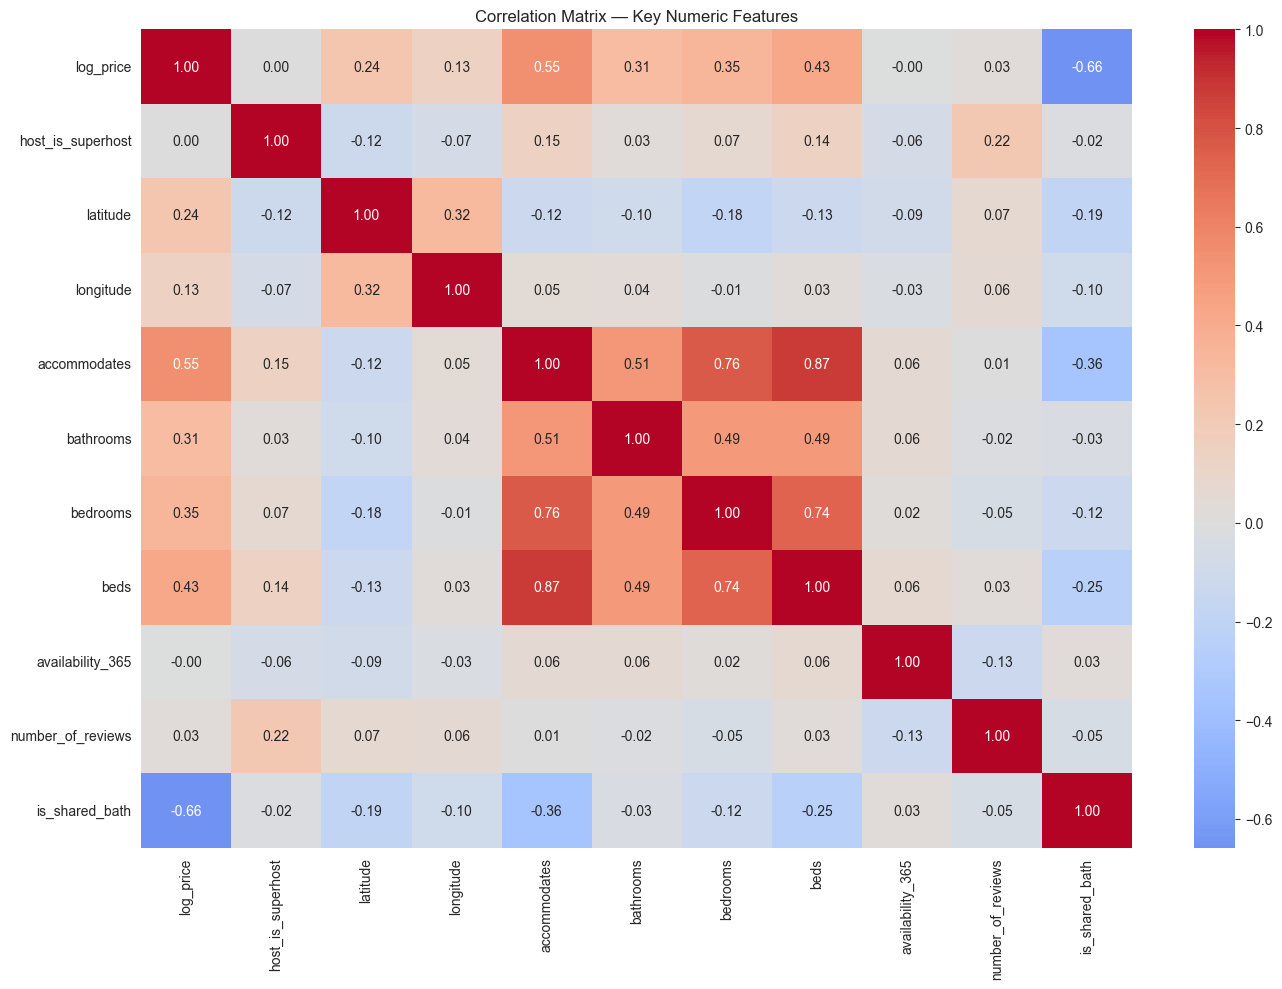

In [53]:


corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix — Key Numeric Features")
plt.tight_layout()
os.makedirs("plots", exist_ok=True)
fig.savefig("plots/correlation_matrix.png", dpi=150, bbox_inches="tight")
plt.show()



## 4. Modeling

In [ ]:
# Final dataset
df.info()
print(df.shape)

<class 'pandas.core.frame.DataFrame'>
Index: 3416 entries, 0 to 4418
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   host_is_superhost      3416 non-null   int64  
 1   latitude               3416 non-null   float64
 2   longitude              3416 non-null   float64
 3   room_type              3416 non-null   object 
 4   accommodates           3416 non-null   int64  
 5   bathrooms              3416 non-null   float64
 6   bedrooms               3416 non-null   float64
 7   beds                   3415 non-null   float64
 8   price                  3416 non-null   float64
 9   availability_365       3416 non-null   int64  
 10  number_of_reviews      3416 non-null   int64  
 11  log_price              3416 non-null   float64
 12  is_high_price          3416 non-null   int64  
 13  is_short_stay          3416 non-null   int64  
 14  property_type_clean    3416 non-null   object 
 15  is_shared

### 4.1 Feature selection

All four models use exactly the same feature set so results are directly comparable.

In [54]:
numeric_features = [
    "host_is_superhost",
    "latitude", "longitude",
    "accommodates", "bathrooms", "bedrooms", "beds",
    "availability_365",
    "number_of_reviews",
    "is_short_stay",
    "is_shared_bath",
    "has_wifi", "has_parking", "has_kitchen",
    "has_ac", "has_self_checkin", "has_pet_allowed"
]

categorical_features = [
    "room_type",
    "property_type_clean",
    "neighbourhood_cleaned",
    "geo_area",
]

X = df[numeric_features + categorical_features]
y = df["log_price"]


print(f"Features  : {len(numeric_features)} numeric  +  {len(categorical_features)} categorical")
print(f"Dataset   : {X.shape[0]} rows  ×  {X.shape[1]} cols")


Features  : 17 numeric  +  4 categorical
Dataset   : 3412 rows  ×  21 cols


### 4.2 Train / test split

Split *before* fitting any imputers or encoders to avoid data leakage.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)
print("Train:", X_train.shape, "  Test:", X_test.shape)

Train: (2391, 21)   Test: (1025, 21)


### 4.3 Preprocessing pipeline
We fit the preprocessor on the training set only, then apply it to both sets.
This avoids data leakage.

In [ ]:
preprocessor = ColumnTransformer(transformers=[
    ("num", Pipeline(steps=[('imputer', SimpleImputer(strategy='mean')), ('scaler', StandardScaler())]), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features)])
preprocessor.fit(X_train)

X_train = preprocessor.transform(X_train)
X_test  = preprocessor.transform(X_test)

print("Transformed shape:", X_train.shape)

Transformed shape: (2391, 56)


### 4.4 Evaluation Helper

A shared helper runs **5-fold CV on the training set** and also reports final metrics on the held-out test set.

In [ ]:
from sklearn.model_selection import cross_validate
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluate_model(name, model, X_train, y_train, X_test, y_test, cv=5):
    """
    1. Fit model on X_train / y_train.
    2. Run k-fold CV (on training data only) → report mean ± std.
    3. Evaluate on held-out X_test / y_test.
    """
    # Cross-validation (training set only)
    cv_results = cross_validate(
        model, X_train, y_train,
        cv=cv,
        scoring={"r2": "r2", "neg_rmse": "neg_root_mean_squared_error"},
        return_train_score=False,
        n_jobs=-1,
    )
    cv_r2   = cv_results["test_r2"]
    cv_rmse = -cv_results["test_neg_rmse"]

    print(f"name: {name}")
    print(f"CV R²: {cv_r2.mean():.4f} ± {cv_r2.std():.4f}")
    print(f"CV RMSE: {cv_rmse.mean():.4f} ± {cv_rmse.std():.4f}")

    # Final fit + test evaluation
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    test_r2   = r2_score(y_test, y_pred)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    test_mae  = mean_absolute_error(np.expm1(y_test), np.expm1(y_pred))

    print(f"Test R²: {test_r2:.4f}")
    print(f"Test RMSE (log): {test_rmse:.4f}")
    print(f"Test MAE ($): ${test_mae:.2f}\n")

    return {
        "Model": name,
        "CV R² (mean)": round(cv_r2.mean(),  4),
        "CV R² (std)":   round(cv_r2.std(),   4),
        "CV RMSE (mean)":round(cv_rmse.mean(),4),
        "Test R²":     round(test_r2,   4),
        "Test RMSE":   round(test_rmse, 4),
        "Test MAE ($)":round(test_mae,  2),
        "model_obj":   model,
        "y_pred":      y_pred,
    }

### 4.5 Linear Regression

Ordinary least-squares regression with the full preprocessed feature set. Serves as the interpretable linear baseline.

In [ ]:
from sklearn.linear_model import LinearRegression

model_lr =  LinearRegression()
res_lr = evaluate_model("Linear Regression", model_lr, X_train, y_train, X_test, y_test)

name: Linear Regression
CV R²: 0.7524 ± 0.0202
CV RMSE: 0.3423 ± 0.0160
Test R²: 0.7192
Test RMSE (log): 0.3609
Test MAE ($): $60.14



### 4.6 Lasso Regression

L1-regularized linear regression. Lasso shrinks less important coefficients to exactly zero, performing automatic feature selection.

In [ ]:
from sklearn.linear_model import LassoCV, Lasso

# find best alpha via CV on training data
lasso_cv = LassoCV(cv=5, random_state=42, max_iter=10000, n_jobs=-1)

lasso_cv.fit(X_train, y_train)
best_alpha_lasso = lasso_cv.alpha_
print(f"Best Lasso alpha: {best_alpha_lasso:.6f}")

# build final model with tuned alpha
model_lasso = Lasso(alpha=best_alpha_lasso, max_iter=10000, random_state=42)
res_lasso = evaluate_model("Lasso", model_lasso, X_train, y_train, X_test, y_test)

Best Lasso alpha: 0.000455
name: Lasso
CV R²: 0.7522 ± 0.0207
CV RMSE: 0.3424 ± 0.0168
Test R²: 0.7219
Test RMSE (log): 0.3592
Test MAE ($): $60.22



### 4.7 Ridge Regression

L2-regularized linear regression. Ridge shrinks all coefficients toward zero but never eliminates them — useful when many features contribute weakly.

In [ ]:
from sklearn.linear_model import RidgeCV, Ridge

# find best alpha via CV on training data
ridge_cv = RidgeCV(cv=5)

ridge_cv.fit(X_train, y_train)
best_alpha_ridge = ridge_cv.alpha_
print(f"Best Ridge alpha: {best_alpha_ridge:.4f}")

# build final model with tuned alpha
model_ridge = Ridge(alpha=best_alpha_ridge)
res_ridge = evaluate_model("Ridge", model_ridge, X_train, y_train, X_test, y_test)

Best Ridge alpha: 1.0000
name: Ridge
CV R²: 0.7526 ± 0.0205
CV RMSE: 0.3421 ± 0.0165
Test R²: 0.7209
Test RMSE (log): 0.3599
Test MAE ($): $60.03



### 4.8 Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeRegressor, plot_tree, export_text
from sklearn.model_selection import GridSearchCV

# Grid search
dt_param_grid = {"max_depth":[3, 5, 8, 10, 15], "min_samples_leaf": [5, 10, 20, 50]}

dt_grid = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    dt_param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1)

dt_grid.fit(X_train, y_train)

print("Best parameters:", dt_grid.best_params_)
print("Best CV R²:", round(dt_grid.best_score_, 4))

Best parameters: {'max_depth': 8, 'min_samples_leaf': 10}
Best CV R²: 0.7474


In [ ]:
# Final model
model_dt = dt_grid.best_estimator_
res_dt   = evaluate_model("Decision Tree", model_dt, X_train, y_train, X_test, y_test)

name: Decision Tree
CV R²: 0.7474 ± 0.0193
CV RMSE: 0.3457 ± 0.0141
Test R²: 0.6896
Test RMSE (log): 0.3795
Test MAE ($): $63.05



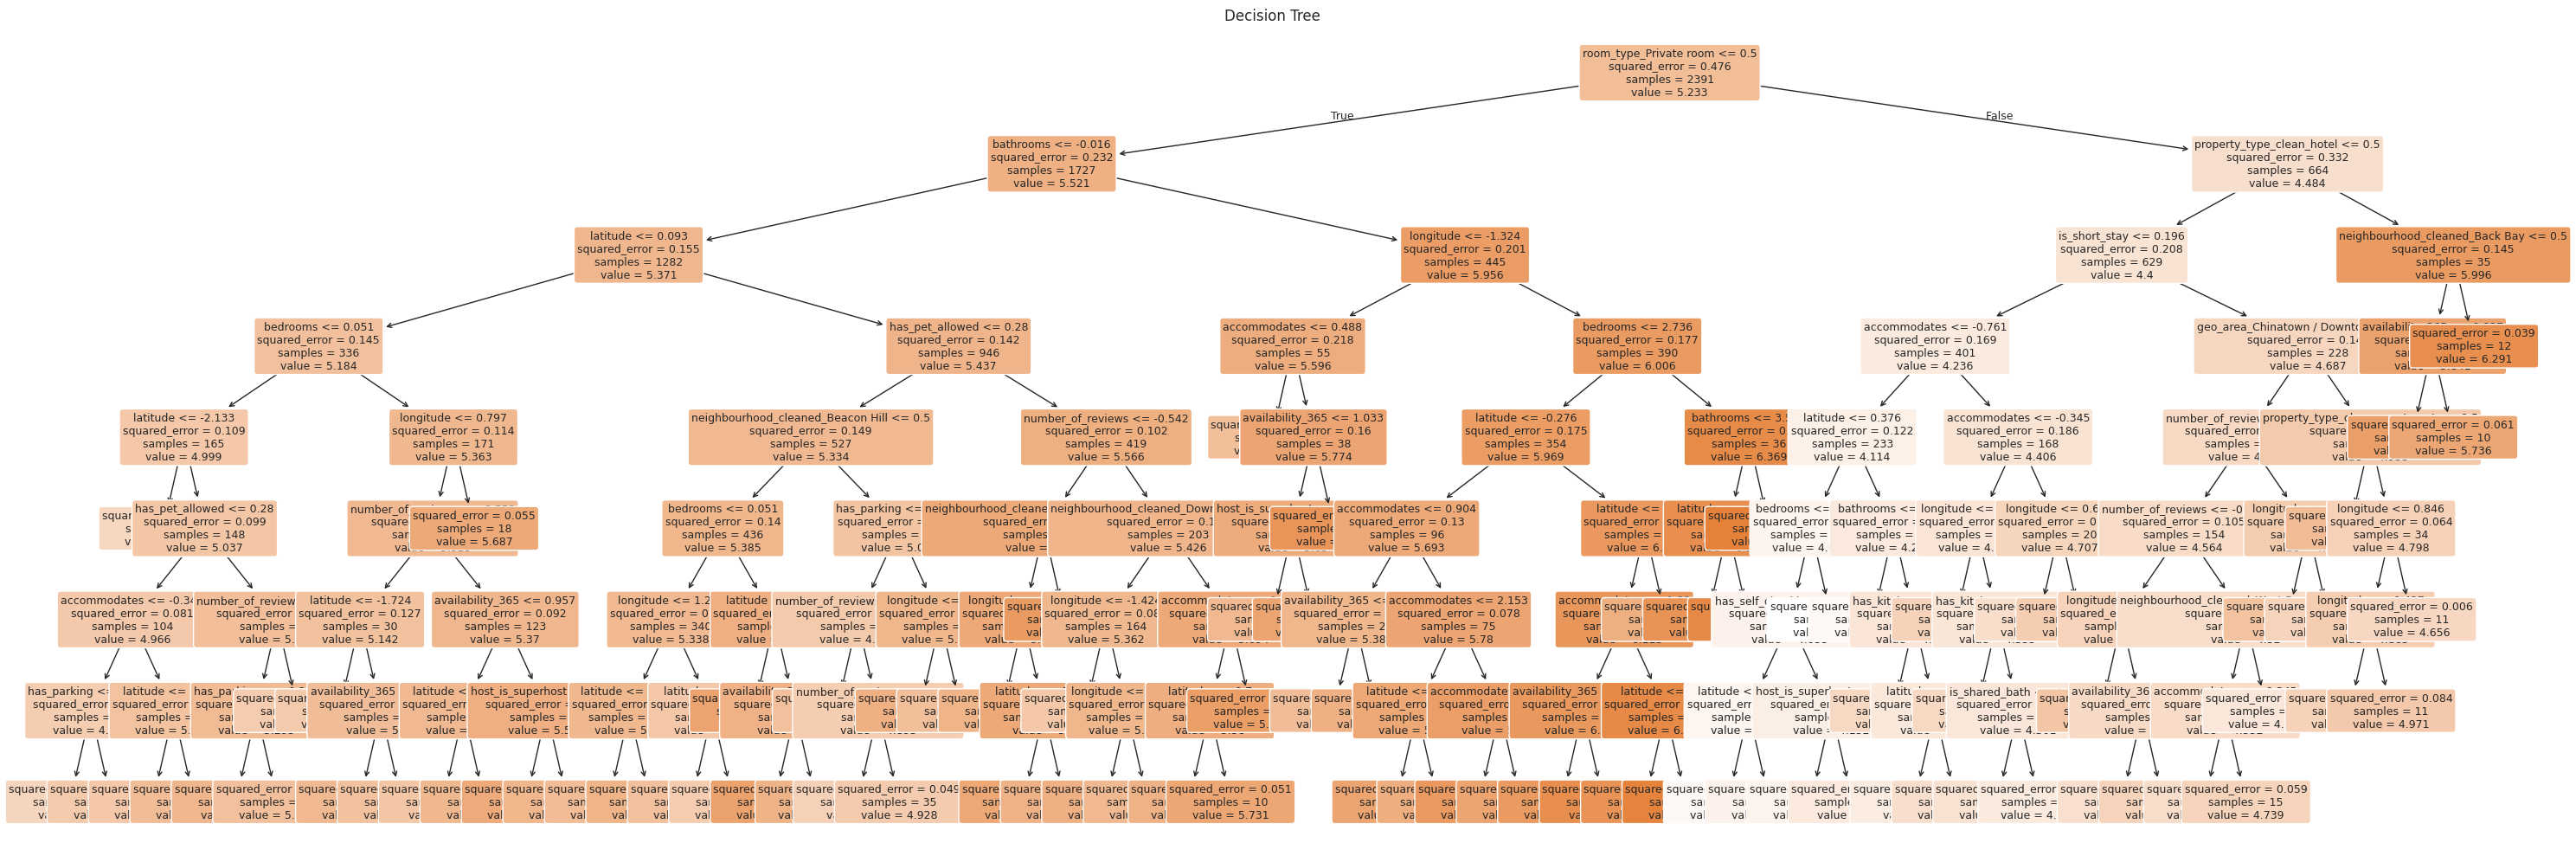

In [ ]:
# Tree visualisation
ohe_names = (preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_features).tolist())
all_feature_names = numeric_features + ohe_names

plt.figure(figsize=(30, 10))
plot_tree(
    model_dt,
    max_depth     = 8,
    feature_names = all_feature_names,
    filled        = True,
    rounded       = True,
    fontsize      = 9)
plt.title("Decision Tree")
plt.tight_layout()
plt.show()

### 4.9 Random Forest

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Grid search
rf_param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20],
    "min_samples_leaf": [1, 2, 5],
    "max_features":["sqrt", 0.5]
}

rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    rf_param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("Best parameters:", rf_grid.best_params_)
print("Best CV R²:", round(rf_grid.best_score_, 4))

Best parameters: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 300}
Best CV R²: 0.8346


In [ ]:
# Final model
model_rf = rf_grid.best_estimator_
res_rf   = evaluate_model("Random Forest", model_rf, X_train, y_train, X_test, y_test)

name: Random Forest
CV R²: 0.8346 ± 0.0131
CV RMSE: 0.2797 ± 0.0124
Test R²: 0.8053
Test RMSE (log): 0.3006
Test MAE ($): $49.09



### 4.10 XGBoost

In [ ]:
from xgboost import XGBRegressor

# Grid search
xgb_param_grid = {
    "n_estimators": [300, 500],
    "learning_rate": [0.01, 0.05],
    "max_depth": [6, 9],
    "subsample": [0.7],
    "colsample_bytree": [0.7, 0.8],
    "reg_lambda": [1, 5]       # L2 regularisation
}

xgb_grid = GridSearchCV(
    XGBRegressor(random_state=42, verbosity=0),
    xgb_param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)
xgb_grid.fit(X_train, y_train)

print("Best parameters:", xgb_grid.best_params_)
print("Best CV R²:", round(xgb_grid.best_score_, 4))

Best parameters: {'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 9, 'n_estimators': 500, 'reg_lambda': 5, 'subsample': 0.7}
Best CV R²: 0.8354


In [ ]:
# Final model
model_xgb = xgb_grid.best_estimator_
res_xgb   = evaluate_model("XGBoost", model_xgb, X_train, y_train, X_test, y_test)

name: XGBoost
CV R²: 0.8354 ± 0.0148
CV RMSE: 0.2790 ± 0.0141
Test R²: 0.8018
Test RMSE (log): 0.3032
Test MAE ($): $48.58



### 4.11 Model Comparison

In [ ]:
all_results = [res_lr, res_lasso, res_ridge, res_dt, res_rf, res_xgb]

summary_df = (
    pd.DataFrame([
        {k: v for k, v in r.items() if k not in ("model_obj", "y_pred")}
        for r in all_results
    ])
    .set_index("Model")
    .sort_values("Test R²", ascending=False)
)

print(" Model Comparison Summary ")
print(summary_df.to_string())

── Model Comparison Summary ──
                   CV R² (mean)  CV R² (std)  CV RMSE (mean)  Test R²  Test RMSE  Test MAE ($)
Model                                                                                         
Random Forest            0.8346       0.0131          0.2797   0.8053     0.3006         49.09
XGBoost                  0.8354       0.0148          0.2790   0.8018     0.3032         48.58
Lasso                    0.7522       0.0207          0.3424   0.7219     0.3592         60.22
Ridge                    0.7526       0.0205          0.3421   0.7209     0.3599         60.03
Linear Regression        0.7524       0.0202          0.3423   0.7192     0.3609         60.14
Decision Tree            0.7474       0.0193          0.3457   0.6896     0.3795         63.05


/tmp/ipykernel_1543/4289787465.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data, x=metric, y="Model", palette=pal, ax=ax)
/tmp/ipykernel_1543/4289787465.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data, x=metric, y="Model", palette=pal, ax=ax)
/tmp/ipykernel_1543/4289787465.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data, x=metric, y="Model", palette=pal, ax=ax)


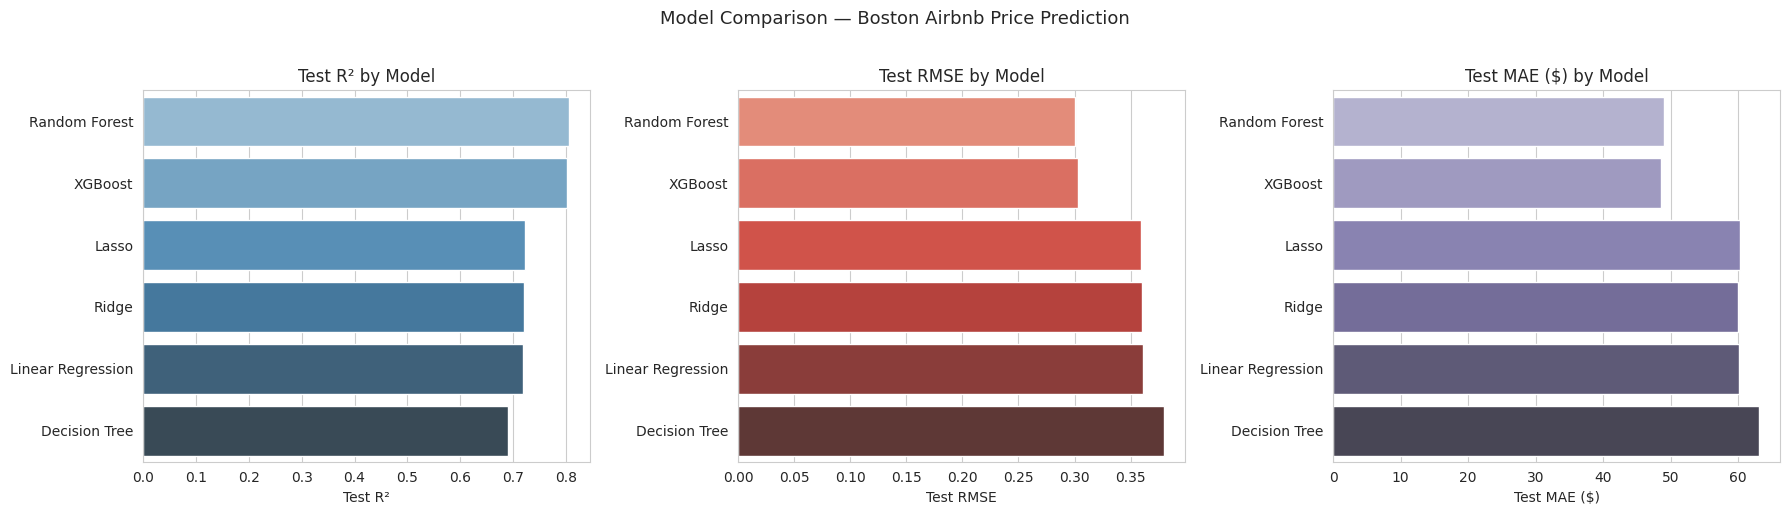

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics  = ["Test R²", "Test RMSE", "Test MAE ($)"]
palettes = ["Blues_d", "Reds_d", "Purples_d"]

for ax, metric, pal in zip(axes, metrics, palettes):
    data = summary_df[metric].reset_index()
    sns.barplot(data=data, x=metric, y="Model", palette=pal, ax=ax)
    ax.set_title(f"{metric} by Model")
    ax.set_ylabel("")

plt.suptitle("Model Comparison — Boston Airbnb Price Prediction", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()